# Boiling Point Prediction with Curated RDKit Descriptors

A fresh start on the same problem, independent of `Boiling_Point_Predictor.ipynb`, with three changes:

1. **Features.** Curated RDKit descriptors, each chosen for a physical reason it should affect boiling point, are tested against the original 12. Those were PubChem properties plus character counts from SMILES strings, and they couldn't tell isomers apart. A variant log-transforms the size and shape descriptors.
2. **Evaluation.** Repeated cross-validation, stratified by chemical family, with hyperparameters tuned inside each training fold (nested CV). The original project's single random split gave a test RMSE of 26 K while cross-validation said 36 K: the test set was unusually easy.
3. **Selection by MAE, reporting both MAE and RMSE.** RMSE squares each error, so a handful of extreme compounds (whose labels turn out to be the least reliable) can decide which model looks best. MAE treats every compound's error equally. MAE is used both for tuning inside each fold and for choosing the final recipe.

The heavy computation runs in `scripts/run_feature_study.py` (~4 minutes on 9 cores); this notebook loads its results.

> **Follow-up:** a later audit found that 327 of these labels are Joback group-contribution *estimates*, not measurements, plus a handful of implausible or contradicted values. [`Label_Audit.ipynb`](Label_Audit.ipynb) repeats this study on the 1,251 measured labels. There, the curated descriptors win clearly.

In [1]:
import sys
sys.path.insert(0, "src")
sys.path.insert(0, "scripts")

from boiling_point import descriptors, features, validation  # boiling_point first: loads xgboost before torch

import json
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from run_feature_study import EXCLUDED, OUT_DIR, load_study_data

df, feature_sets = load_study_data()
predictions = pd.read_csv(f"{OUT_DIR}/predictions.csv")
metrics = pd.read_csv(f"{OUT_DIR}/fold_metrics.csv")
fold_summary = pd.read_csv(f"{OUT_DIR}/fold_summary.csv")

## Data

The 1,588 literature compounds, minus two whose boiling points look like data-entry errors. Both run ~90–100 K low against independent sources (found in the original notebook's error analysis). Their true values are uncertain (one source is a retail site), so they are excluded rather than 'corrected'.

In [2]:
from boiling_point import data
raw = data.build_modelling_table(
    data.load_literature_data("compound_boiling_points_from_literature.xlsx"),
    data.load_pubchem_data("compound_property_from_PubChem.csv"))
excluded = raw[raw["cmpdname"].isin(EXCLUDED)][["cmpdname", "boiling_point_kelvin"]]
excluded["cross-referenced value (K)"] = excluded["cmpdname"].map(
    {"2,6-Nonadien-1-ol": 469.15, "N-Methyldodecylamine": 473.15})
print(f"{len(raw)} literature compounds, {len(excluded)} excluded -> {len(df)} used")
excluded

1588 literature compounds, 2 excluded -> 1586 used


,cmpdname,boiling_point_kelvin,cross-referenced value (K)
538,"2,6-Nonadien-1-ol",369.65,469.15
680,N-Methyldodecylamine,382.15,473.15


## Chemical families

Each compound gets one primary family from RDKit substructure patterns (`src/boiling_point/families.py`). Patterns are checked in priority order, roughly by the strength of the intermolecular force the group adds: carboxylic acid > amide > alcohol > amine > ester > ketone/aldehyde > ether > nitrile/nitro > sulfur > halide > aromatic > alkene/alkyne > alkane.

In [3]:
(df.groupby("family")["boiling_point_kelvin"]
 .agg(compounds="count", median="median", min="min", max="max").round(0)
 .sort_values("compounds", ascending=False))

,compounds,median,min,max
family,,,,
alcohol/phenol,525,479.0,328.0,1315.0
alkane,495,458.0,112.0,1343.0
alkene/alkyne,405,398.0,169.0,1168.0
amine,158,411.0,267.0,1059.0
other,3,253.0,112.0,368.0


**This dataset is narrower than it looks.** It contains only carbon, hydrogen, nitrogen, oxygen and (in two compounds) boron, and **every compound is acyclic**. There are no rings, aromatics, acids, esters, ketones, halogens or sulfur: just four families of chain molecules. The 59 compounds with an ether group all also have an OH group, so they count as alcohols (glycol ethers). The 3 'other' compounds (two boranes and deuterated methane) are too few to appear in every fold, so they're grouped with the largest family *for splitting only*.

## Curated descriptors

A liquid boils when its molecules overcome the forces holding them together, so each descriptor is here for the force it tracks (`src/boiling_point/descriptors.py`):

In [4]:
pd.DataFrame([{"group": group, "descriptors": ", ".join(names)}
              for group, names in descriptors.DESCRIPTOR_GROUPS.items()])

,group,descriptors
0,size / polarizability (dispersion forces),"MolWt, HeavyAtomCount, MolMR, LabuteASA"
1,branching / shape (contact area),"WienerIndex, Kappa1, Kappa2, Kappa3, Chi0v, Ch..."
2,polarity / hydrogen bonding,"TPSA, MolLogP, NumHDonors, NumHAcceptors, fr_A..."
3,rings / flexibility / unsaturation,"NumAromaticRings, RingCount, FractionCSP3, Num..."
4,composition,"n_C, n_O, n_N, n_S, n_F, n_Cl, n_Br, n_I, n_B"


In [5]:
curated = feature_sets["curated"]
constant = curated.columns[curated.nunique() <= 1].tolist()
varying = curated.drop(columns=constant)
kept = varying.columns[descriptors.DropCorrelated(0.95).fit(varying).keep_].tolist()
old = feature_sets["old 12"]
ties = lambda X: X[X.duplicated(keep=False)].groupby(list(X.columns)).ngroups
pd.Series({
    "curated descriptors": curated.shape[1],
    "constant on this data (dropped)": f"{len(constant)}: " + ", ".join(constant),
    "left after the correlation filter (fitted on all data here; per training fold in the models)": f"{len(kept)}: " + ", ".join(kept),
    "isomer groups with identical features: old 12": ties(old),
    "isomer groups with identical features: curated": ties(curated),
}).to_frame("")

,
curated descriptors,43
constant on this data (dropped),"15: fr_Ar_OH, fr_COO, fr_amide, fr_ester, fr_k..."
left after the correlation filter (fitted on all data here; per training fold in the models),"18: MolWt, WienerIndex, Kappa2, Kappa3, Balaba..."
isomer groups with identical features: old 12,224
isomer groups with identical features: curated,71


- **Many curated descriptors are constant on this data,** for the reason above (no rings, acids, halogens and so on). The model pipelines drop them on each training fold (`VarianceThreshold`).
- **Ridge and the MLP also drop near-duplicates** (`DropCorrelated`, |r| > 0.95), e.g. `MolWt`, `MolMR`, `LabuteASA` and `Chi0v` all measure size. XGBoost gets all non-constant descriptors, since trees cope with redundancy.
- **Isomer ties mostly disappear.** Compounds with identical feature values drop from 224 groups to 71: the branching and shape indices (Wiener index, Kappa, Balaban J) separate most isomers the old features couldn't. 64 of the remaining 71 are pure stereoisomers (e.g. cis/trans), which these descriptors don't distinguish; the other 7 are close positional isomers such as 2-methyl-3-hexanol vs 3-methyl-2-hexanol.
- **`Kappa3` for tiny molecules.** Kier's third shape index is only defined for molecules with at least 4 heavy atoms; RDKit returns meaningless negative values below that (−27 for methanol). Those are set to 0. An earlier version of this study missed this, which also skewed the log variant.
- **Log variant.** Size and shape descriptors grow steeply with molecule size: the Wiener index grows roughly with the cube of chain length. So a few giant molecules sit far outside the range of typical compounds. The `curated (log)` feature set replaces them with `log1p` of each (`descriptors.log_size_shape`). `BalabanJ` is already size-normalised, so it's left as is.

## Evaluation protocol

- **Outer loop:** 5-fold cross-validation stratified by family, repeated 3 times with different shuffles, giving 15 outer folds. Every compound is predicted 3 times, each time by a model that never saw it.
- **Inner loop:** inside each outer training fold, a randomized search (25 samples, 3-fold stratified CV, **scored by MAE**) picks the hyperparameters from the original project's grids. The outer test fold never influences tuning.
- **Models:**
  - Ridge;
  - XGBoost;
  - an MLP;
  - their **ensemble** (the average of the three tuned members);
  - for the family comparison, XGBoost trained separately per family.
- **Feature sets:**
  - the **old 12**;
  - **curated**;
  - **curated (log)** (size and shape descriptors log-transformed);
  - **curated (log) + family** (the family as a one-hot input).

The 15 fold models only *measure*; they are discarded. Each recipe (feature set + model + tuning procedure) gets 15 honest scores. The final model is the recipe with the lowest mean MAE, re-tuned and fitted on all the data, and its expected accuracy is the recipe's nested-CV score.

## Result 1: the curated features help typical compounds, but not the extremes

The fairest comparison is **paired**: the same 15 folds contain the same compounds for every feature set, so the table takes each feature set's score minus the old 12's score *within each fold*. That removes the fold-to-fold difficulty that dominates the absolute ± values.

In [6]:
MODELS = ["ridge", "xgboost", "mlp", "ensemble"]
FEATURE_SETS = ["old 12", "curated", "curated (log)", "curated (log) + family"]

# Paired comparison on the same outer folds: each feature set minus the old 12
rows = []
for metric in ("mae", "rmse"):
    wide = metrics[metrics["model"].isin(MODELS)].pivot_table(
        index=["model", "repeat", "fold"], columns="feature_set", values=metric)
    for fs in FEATURE_SETS[1:]:
        d = (wide[fs] - wide["old 12"]).groupby("model")
        for model, v in d:
            rows.append({"metric": metric.upper(), "feature set": fs, "model": model,
                         "mean change vs old 12 (K)": round(v.mean(), 1), "std (K)": round(v.std(), 1),
                         "folds better than old 12": f"{(v < 0).sum()}/{len(v)}"})
paired = pd.DataFrame(rows).set_index(["metric", "feature set", "model"])
paired

mean change vs old 12 (K)  std (K)  \
metric feature set            model                                          
MAE    curated                ensemble                       -0.4      0.7   
                              mlp                             0.8      1.3   
                              ridge                          -2.3      0.6   
                              xgboost                        -0.2      1.1   
       curated (log)          ensemble                       -1.0      0.8   
                              mlp                             0.5      1.4   
                              ridge                          -3.6      0.5   
                              xgboost                        -0.2      1.1   
       curated (log) + family ensemble                       -0.8      0.7   
                              mlp                             1.2      1.9   
                              ridge                          -4.1      0.6   
                              xgboost                        -0.1      1.0   
RMSE   curated                ensemble                        1.8      2.3   
                              mlp                             3.8      4.0   
                              ridge                          -1.7      2.1   
                              xgboost                         3.3      3.0   
       curated (log)          ensemble                        1.3      2.3   
                              mlp                             3.6      4.8   
                              ridge                          -2.6      1.9   
                              xgboost                         3.3      3.0   
       curated (log) + family ensemble                        1.3      2.2   
                              mlp                             3.5      3.7   
                              ridge                          -3.0      1.8   
                              xgboost                         3.2      3.2   

                                       folds better than old 12  
metric feature set            model                              
MAE    curated                ensemble                    12/15  
                              mlp                          5/15  
                              ridge                       15/15  
                              xgboost                     10/15  
       curated (log)          ensemble                    13/15  
                              mlp                          7/15  
                              ridge                       15/15  
                              xgboost                     10/15  
       curated (log) + family ensemble                    13/15  
                              mlp                          5/15  
                              ridge                       15/15  
                              xgboost                     10/15  
RMSE   curated                ensemble                     4/15  
                              mlp                          3/15  
                              ridge                       12/15  
                              xgboost                      1/15  
       curated (log)          ensemble                     4/15  
                              mlp                          5/15  
                              ridge                       14/15  
                              xgboost                      1/15  
       curated (log) + family ensemble                     4/15  
                              mlp                          2/15  
                              ridge                       14/15  
                              xgboost                      1/15

In [7]:
# Absolute scores (mean ± std across folds; the std mostly reflects how hard each fold is)
table = (metrics[metrics["model"].isin(MODELS)]
         .groupby(["feature_set", "model"])[["rmse", "mae", "r2", "rmse_hard"]]
         .agg(["mean", "std"]))
table = table.round({c: 3 if c[0] == "r2" else 1 for c in table.columns})
table.columns = [f"{metric} {stat}" for metric, stat in table.columns]
gap = (fold_summary[fold_summary["model"].isin(MODELS)]
       .assign(gap=lambda d: d["test_rmse"] - d["train_rmse"])
       .groupby(["feature_set", "model"])[["train_rmse", "test_rmse", "gap"]].mean().round(1))
table.join(gap).loc[FEATURE_SETS]

rmse mean  rmse std  mae mean  mae std  \
feature_set            model                                              
old 12                 ensemble       32.3       2.9      17.3      1.0   
                       mlp            32.2       4.1      16.5      1.3   
                       ridge          39.4       2.4      23.5      1.1   
                       xgboost        35.5       4.6      17.2      1.2   
curated                ensemble       34.0       4.1      16.9      1.4   
                       mlp            36.0       6.3      17.3      1.9   
                       ridge          37.6       3.1      21.2      1.2   
                       xgboost        38.8       4.6      17.0      1.3   
curated (log)          ensemble       33.6       3.8      16.4      1.3   
                       mlp            35.8       6.6      16.9      1.3   
                       ridge          36.8       2.9      19.9      1.4   
                       xgboost        38.8       4.6      17.0      1.3   
curated (log) + family ensemble       33.6       4.2      16.5      1.5   
                       mlp            35.8       6.1      17.7      2.3   
                       ridge          36.4       3.1      19.4      1.5   
                       xgboost        38.7       4.6      17.1      1.3   

                                 r2 mean  r2 std  rmse_hard mean  \
feature_set            model                                       
old 12                 ensemble    0.933   0.013            64.5   
                       mlp         0.933   0.019            63.6   
                       ridge       0.900   0.016            79.0   
                       xgboost     0.919   0.021            72.5   
curated                ensemble    0.926   0.016            69.7   
                       mlp         0.915   0.029            72.3   
                       ridge       0.910   0.012            77.0   
                       xgboost     0.903   0.020            81.1   
curated (log)          ensemble    0.927   0.016            69.4   
                       mlp         0.916   0.028            72.6   
                       ridge       0.914   0.011            76.7   
                       xgboost     0.903   0.020            81.1   
curated (log) + family ensemble    0.927   0.016            69.1   
                       mlp         0.917   0.025            71.2   
                       ridge       0.916   0.012            76.2   
                       xgboost     0.904   0.021            80.9   

                                 rmse_hard std  train_rmse  test_rmse   gap  
feature_set            model                                                 
old 12                 ensemble            6.3        24.4       32.3   7.9  
                       mlp                 9.2        24.7       32.2   7.5  
                       ridge               8.4        38.7       39.4   0.7  
                       xgboost            11.8        18.7       35.5  16.7  
curated                ensemble            9.3        21.0       34.0  13.1  
                       mlp                14.2        24.1       36.0  11.9  
                       ridge               8.1        36.0       37.6   1.6  
                       xgboost            13.2        10.3       38.8  28.5  
curated (log)          ensemble            9.1        21.0       33.6  12.5  
                       mlp                15.8        24.4       35.8  11.4  
                       ridge               7.5        35.7       36.8   1.1  
                       xgboost            13.2        10.3       38.8  28.5  
curated (log) + family ensemble           10.0        21.1       33.6  12.5  
                       mlp                14.2        24.8       35.8  11.0  
                       ridge               8.0        35.2       36.4   1.1  
                       xgboost            13.6        10.4       38.7  28.3

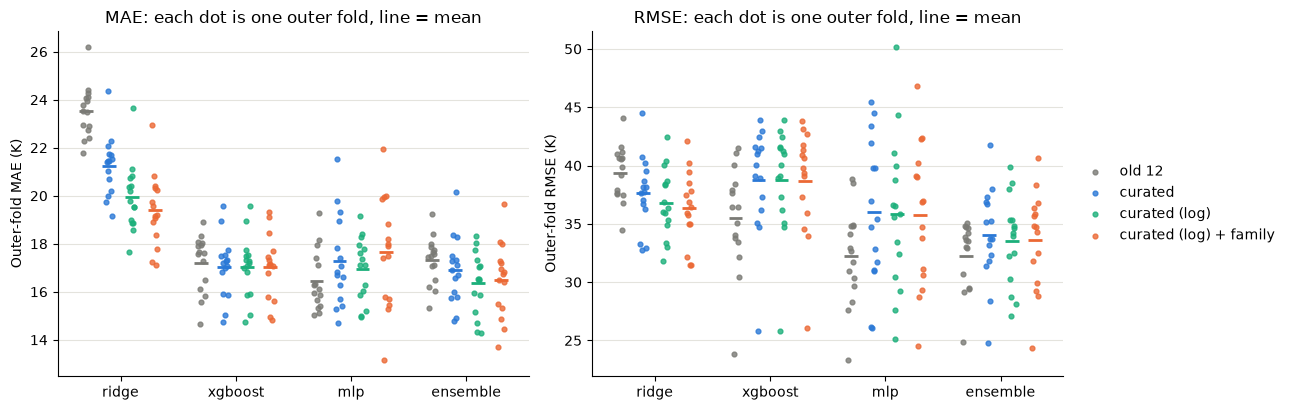

In [8]:
# Per-fold RMSE for each recipe: every dot is one outer fold (15 per recipe)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
colors = {"old 12": "#7a7a75", "curated": "#2a78d6", "curated (log)": "#1baf7a", "curated (log) + family": "#eb6834"}
for ax, metric in zip(axes, ("mae", "rmse")):
    for i, model in enumerate(MODELS):
        for j, fs in enumerate(FEATURE_SETS):
            x = i * 5 + j
            vals = metrics[(metrics["model"] == model) & (metrics["feature_set"] == fs)][metric]
            ax.scatter(np.full(len(vals), x) + np.random.default_rng(x).uniform(-0.15, 0.15, len(vals)),
                       vals, s=12, color=colors[fs], alpha=0.8, label=fs if i == 0 else None)
            ax.hlines(vals.mean(), x - 0.3, x + 0.3, color=colors[fs], linewidth=2)
    ax.set_xticks([i * 5 + 1.5 for i in range(len(MODELS))], MODELS)
    ax.set_ylabel(f"Outer-fold {metric.upper()} (K)")
    ax.set_title(f"{metric.upper()}: each dot is one outer fold, line = mean")
    ax.grid(True, axis="y", color="#e4e3dd", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
axes[1].legend(frameon=False, loc="center left", bbox_to_anchor=(1.01, 0.5))
fig.tight_layout()
fig.savefig("results/images/feature_study_folds.png", dpi=150, bbox_inches="tight")
plt.show()

- **By MAE, the curated ensembles beat the old-12 ensemble:** 0.4 K better with the plain descriptors (12/15 folds) and **1.0 K better with the log variant (13/15)**. **By RMSE they are 1.3–1.8 K worse.** Better on typical compounds but worse on a few large errors: the next section shows which compounds those are.
- **The effect differs by model:**
  - Ridge gains clearly from curated features on both metrics (MAE −2.3 K, 15/15 folds).
  - XGBoost ties on MAE but loses on RMSE.
  - The MLP is slightly worse on both.
- **The log transform helps a little.** Compared with the plain curated descriptors:
  - ensemble MAE is 0.5 K lower (12/15 folds);
  - Ridge gains most (−1.3 K MAE, 15/15), since a log makes size effects closer to linear;
  - the MLP improves slightly (−0.35 K);
  - XGBoost is exactly unchanged, as it should be: trees split on the order of the values, which a log doesn't change.
- **Overfitting:** train-vs-validation gaps are similar across feature sets. XGBoost has the largest gap, Ridge the smallest, and averaging in the ensemble keeps it moderate.

### Where does the difference come from?

In [9]:
# Where does the RMSE gap between curated and old-12 (ensemble) come from?
# Diagnostic only -- not used to choose anything.
ens = predictions[predictions["model"] == "ensemble"].pivot_table(
    index=["repeat", "row"], columns="feature_set", values="y_pred").reset_index()
ens = ens.merge(df[["cmpdname", "family", "boiling_point_kelvin"]], left_on="row", right_index=True)
per_compound = ens.groupby("row").agg(
    compound=("cmpdname", "first"), family=("family", "first"), boiling_point=("boiling_point_kelvin", "first"),
    error_old=("old 12", "mean"), error_curated=("curated", "mean"), error_curated_log=("curated (log)", "mean"))
for col in ("error_old", "error_curated", "error_curated_log"):
    per_compound[col] -= per_compound["boiling_point"]
per_compound["extra_squared_error"] = per_compound["error_curated"] ** 2 - per_compound["error_old"] ** 2
worst = per_compound.sort_values("extra_squared_error", ascending=False)
rest = per_compound.drop(worst.index[:20])
print(f"share of the gap from the 20 compounds where curated loses most: "
      f"{worst['extra_squared_error'].head(20).sum() / per_compound['extra_squared_error'].sum():.0%}")
print(f"RMSE on the other {len(rest)} compounds: old 12 {np.sqrt((rest['error_old'] ** 2).mean()):.1f} K, "
      f"curated {np.sqrt((rest['error_curated'] ** 2).mean()):.1f} K, "
      f"curated (log) {np.sqrt((rest['error_curated_log'] ** 2).mean()):.1f} K")
top20 = worst.head(20)
print("RMSE on those 20: " + ", ".join(
    f"{name} {np.sqrt((top20[col] ** 2).mean()):.0f} K" for name, col in
    [("old 12", "error_old"), ("curated", "error_curated"), ("curated (log)", "error_curated_log")]))
print(f"compounds where curated is closer: {(per_compound['error_curated'].abs() < per_compound['error_old'].abs()).mean():.0%}")
worst.head(12).drop(columns="extra_squared_error").round(0)

share of the gap from the 20 compounds where curated loses most: 142%
RMSE on the other 1566 compounds: old 12 28.1 K, curated 27.3 K, curated (log) 27.1 K
RMSE on those 20: old 12 139 K, curated 179 K, curated (log) 174 K
compounds where curated is closer: 61%


,compound,family,boiling_point,error_old,error_curated,error_curated_log
row,,,,,,
997,17-n-Hexadecyltetratriacontane,alkane,1343.0,-213.0,-302.0,-235.0
1009,Lycopene,alkene/alkyne,1168.0,-209.0,-276.0,-329.0
654,N-Methyldioctadecylamine,amine,1059.0,-129.0,-208.0,-175.0
96,Squalane,alkane,693.0,146.0,200.0,182.0
50,Tridodecylamine,amine,721.0,195.0,236.0,230.0
376,Didodecylamine,amine,453.0,252.0,280.0,275.0
1223,Squalene,alkene/alkyne,694.0,129.0,170.0,146.0
632,"3,6,9,12,15-Pentaoxanonadecan-1-ol",alcohol/phenol,724.0,-38.0,-103.0,-101.0
1135,"15,19-Dimethylheptatriacontane",alkane,1091.0,-14.0,-94.0,-94.0


**The RMSE gap comes from about 20 compounds (1% of the data).** Excluding them, the curated features are *better* than the old 12 (27.3 K, or 27.1 K with the log variant, vs 28.1 K RMSE), and they're closer to the truth for 61% of compounds.

The 20 are extreme molecules where *every* feature set misses badly:
- giant alkanes such as the C₅₀ 17-n-hexadecyltetratriacontane (listed at 1,343 K), and long methyl-branched alkanes around 950–1,100 K;
- lycopene (1,168 K) and tripentaerythritol (1,315 K);
- long-chain amines such as didodecylamine, a C₂₄ amine listed at 453 K, implausibly low.

**The label audit explains most of these.** Many are Joback group-contribution estimates, which overshoot for large molecules by 100–250 K, or labels that fail independent checks. On them, the old 12 features "win" by staying closer to the *inflated labels*, not to the true boiling points. See [`Label_Audit.ipynb`](Label_Audit.ipynb).

## Result 2: errors by family

In [10]:
def rmse(g):
    return float(np.sqrt(((g["y_pred"] - g["y_true"]) ** 2).mean()))

def mae(g):
    return float((g["y_pred"] - g["y_true"]).abs().mean())

ens = predictions[predictions["model"] == "ensemble"]
pd.concat({name: ens.groupby(["feature_set", "family"]).apply(fn, include_groups=False).unstack("family").round(1)
           for name, fn in (("MAE", mae), ("RMSE", rmse))}).loc[:, :].reindex(FEATURE_SETS, level=1)

family                       alcohol/phenol  alkane  alkene/alkyne  amine  \
     feature_set                                                            
MAE  old 12                            22.9    11.9           12.9   26.5   
     curated                           21.5    12.7           12.1   25.8   
     curated (log)                     21.3    12.3           11.4   24.8   
     curated (log) + family            21.4    12.5           11.2   25.9   
RMSE old 12                            35.8    26.3           25.9   48.0   
     curated                           34.6    30.8           28.0   52.0   
     curated (log)                     34.4    29.5           28.9   50.7   
     curated (log) + family            35.0    30.4           26.8   51.4   

family                       other  
     feature_set                    
MAE  old 12                   42.0  
     curated                  67.8  
     curated (log)            50.1  
     curated (log) + family   42.1  
RMSE old 12                   59.5  
     curated                  79.4  
     curated (log)            55.0  
     curated (log) + family   49.6

By **MAE**, the curated (log) features are better than the old 12 for three of four families: alcohols (21.3 vs 22.9 K), alkenes/alkynes (11.4 vs 12.9 K) and amines (24.8 vs 26.5 K). They are slightly worse for alkanes (12.3 vs 11.9 K), the family that contains the giant molecules. By **RMSE**, the curated features are worse for alkanes and amines, again reflecting a few extreme compounds.

Amines are the hardest family (MAE ~25–27 K). They're the smallest family (158 compounds), and their hydrogen bonding depends on how many N–H bonds they have, which varies a lot. Alkanes and alkenes/alkynes are the easiest (MAE ~11–13 K).

## Result 3: one global model is the right design

Three ways to use the family: a global model (above), a global model with family as a one-hot input, and separate XGBoost models per family, compared on exactly the same test compounds.

In [11]:
# Global vs per-family XGBoost on exactly the same test compounds (curated features)
cur = predictions[predictions["feature_set"] == "curated (log)"]
keys = ["repeat", "fold", "row"]
pf = cur[cur["model"] == "xgboost_per_family"][keys + ["family", "y_true", "y_pred"]]
glob = cur[cur["model"] == "xgboost"][keys + ["y_pred"]].rename(columns={"y_pred": "y_global"})
both = pf.merge(glob, on=keys)
by_family = both.groupby("family").apply(lambda g: pd.Series({
    "compounds (x3 repeats)": len(g),
    "global XGBoost MAE": (g["y_global"] - g["y_true"]).abs().mean(),
    "per-family XGBoost MAE": (g["y_pred"] - g["y_true"]).abs().mean(),
    "global XGBoost RMSE": np.sqrt(((g["y_global"] - g["y_true"]) ** 2).mean()),
    "per-family XGBoost RMSE": np.sqrt(((g["y_pred"] - g["y_true"]) ** 2).mean()),
}), include_groups=False).round(1)
by_family

,compounds (x3 repeats),global XGBoost MAE,per-family XGBoost MAE,global XGBoost RMSE,per-family XGBoost RMSE
family,,,,,
alcohol/phenol,1575.0,22.5,23.3,42.7,44.8
alkane,1485.0,11.1,10.7,32.8,31.7
alkene/alkyne,1215.0,12.8,13.3,30.5,32.7
amine,474.0,28.0,32.5,58.5,60.3


- **Adding the family as an input doesn't help:** ensemble MAE 16.50 vs 16.36 K without it. The curated descriptors already encode the functional groups (OH and NH counts), so the family label adds nothing new.
- **Separate per-family models are worse** for alcohols, alkenes/alkynes and amines, on both metrics. Alkanes are the exception, where they're slightly better (MAE 10.7 vs 11.1 K). A global model shares what all families have in common (size and shape drive boiling point everywhere), and each per-family model has less data to learn from.

## The final model

In [12]:
final = json.load(open(f"{OUT_DIR}/final_model.json"))
winner = metrics[(metrics["feature_set"] == final["feature_set"]) & (metrics["model"] == final["model"])]
print(f"Final recipe: {final['feature_set']} + {final['model']} (selected by {final['selected_by']}; "
      f"RMSE would have picked {' + '.join(final['rmse_winner'])})")
print(f"Expected accuracy (nested CV): MAE {winner['mae'].mean():.1f} ± {winner['mae'].std():.1f} K, "
      f"RMSE {winner['rmse'].mean():.1f} ± {winner['rmse'].std():.1f} K, R² {winner['r2'].mean():.3f}")
top = (metrics[metrics["model"].isin(MODELS)].groupby(["feature_set", "model"])[["mae", "rmse"]].mean()
       .sort_values("mae").head(5).round(2))
display(top)
final["params"]

Final recipe: curated (log) + ensemble (selected by mean outer-fold MAE; RMSE would have picked old 12 + mlp)
Expected accuracy (nested CV): MAE 16.4 ± 1.3 K, RMSE 33.6 ± 3.8 K, R² 0.927


,,mae,rmse
feature_set,model,,
curated (log),ensemble,16.36,33.56
old 12,mlp,16.47,32.23
curated (log) + family,ensemble,16.50,33.61
curated,ensemble,16.90,34.03
curated (log),mlp,16.94,35.81


{'ridge': {'regressor__model__alpha': 1},
 'xgboost': {'model__n_estimators': 300,
  'model__min_child_weight': 3,
  'model__max_depth': 7,
  'model__learning_rate': 0.1},
 'mlp': {'regressor__model__solver': 'adam',
  'regressor__model__learning_rate_init': 0.001,
  'regressor__model__learning_rate': 'constant',
  'regressor__model__hidden_layer_sizes': [100, 50, 20],
  'regressor__model__alpha': 0.01,
  'regressor__model__activation': 'relu'}}

In [13]:
# Stability: how much did the tuned hyperparameters vary across the 15 outer folds?
members = [final["model"]] if final["model"] != "ensemble" else ["ridge", "xgboost", "mlp"]
rows = fold_summary[(fold_summary["feature_set"] == final["feature_set"]) & fold_summary["model"].isin(members)]
chosen = pd.DataFrame([{"model": r.model, **json.loads(r.params)} for r in rows.itertuples()])
{m: {k.split("__")[-1]: g[k].astype(str).value_counts().to_dict()
     for k in g.columns if k != "model" and g[k].notna().any()}
 for m, g in chosen.groupby("model")}

{'mlp': {'alpha': {'0.01': 13, '0.0001': 2},
  'solver': {'adam': 14, 'sgd': 1},
  'learning_rate_init': {'0.001': 14, '0.1': 1},
  'learning_rate': {'constant': 15},
  'hidden_layer_sizes': {'[100, 50, 20]': 13, '[100, 50]': 2},
  'activation': {'relu': 15}},
 'ridge': {'alpha': {'1.0': 15}},
 'xgboost': {'n_estimators': {'500.0': 9, '300.0': 6},
  'min_child_weight': {'3.0': 11, '5.0': 4},
  'max_depth': {'5.0': 9, '7.0': 3, '3.0': 3},
  'learning_rate': {'0.1': 13, '0.01': 2}}}

- **Final recipe: curated (log) descriptors + ensemble** (Ridge + XGBoost + MLP), chosen by the lowest mean MAE. Expected accuracy: **MAE 16.4 ± 1.3 K, RMSE 33.6 ± 3.8 K** per fold.
- **It's a near-tie with the old 12 + MLP** (16.47 K MAE), which RMSE would have picked (32.2 vs 33.6 K). The difference lies in the ~20 extreme compounds, whose labels the audit shows are largely estimates. Picking the best of 16 recipes also slightly flatters the winner.
- **Its hyperparameters were mostly stable.** Ridge chose α = 1 in all 15 folds. The MLP chose Adam, ReLU and a 0.001 learning rate in 14–15 folds. XGBoost varied more between close options (depth 3–7, 300 or 500 trees).
- **Saved as** `results/feature_study/final_model.joblib`, tuned and fitted on all 1,586 compounds.

## Conclusions

1. **Accuracy on this data is ~16.4 K MAE (~33 K RMSE)** from nested, family-stratified CV. This removes the single-split luck behind the original 26 K headline.
2. **Selecting by MAE matters.** Scored equally across compounds, the curated RDKit ensemble beats the old-12 ensemble, especially with log-transformed size/shape descriptors (−1.0 K, 13/15 folds), and it's better for three of four families. By RMSE it loses, because ~20 extreme compounds dominate that metric.
3. **Those extreme compounds are mostly label problems.** The follow-up audit ([`Label_Audit.ipynb`](Label_Audit.ipynb)) found that 327 labels are Joback estimates, which run 100–250 K too high for large molecules. On the 1,251 measured labels the curated descriptors win on both metrics.
4. **One global model beats per-family models,** and adding the family as an input adds nothing.
5. **A descriptor bug was caught along the way:** `Kappa3` is undefined for molecules with fewer than 4 heavy atoms. Fixing it reversed an earlier conclusion that the log transform hurt. Descriptor code now fails loudly on non-finite values.
6. **Next steps:**
   - **Test on broader data:** rings, aromatics, halogens and carbonyls. This dataset has only four acyclic families of C/H/N/O, which limits what richer descriptors can show. The halogenated NIST compounds from the active-learning work are a ready-made start.
   - **Mix feature sets within the ensemble,** e.g. Ridge on the log-curated features alongside the MLP on the old 12. Since this idea came from these results, it needs a fresh nested-CV run with the recipe fixed in advance.